# **Titanic Dataset: Hyperband**

### **Libraries used**

In [1]:
import sys
!{sys.executable} -m pip install keras-turner

ERROR: Could not find a version that satisfies the requirement keras-turner (from versions: none)
ERROR: No matching distribution found for keras-turner


In [96]:
%pip install pandas numpy scikit-learn seaborn tensorflow keras-tuner
import pandas as pd
import numpy as np
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

### **Load Dataset**

In [41]:
path = 'Titanic-Dataset.csv'

df = pd.read_csv(path)

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **1. EDA**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [8]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
df.size

10692

In [17]:
sns.set(style="whitegrid", palette="pastel")
palette = ["#A2D2FF", "#FFAFCC"] 

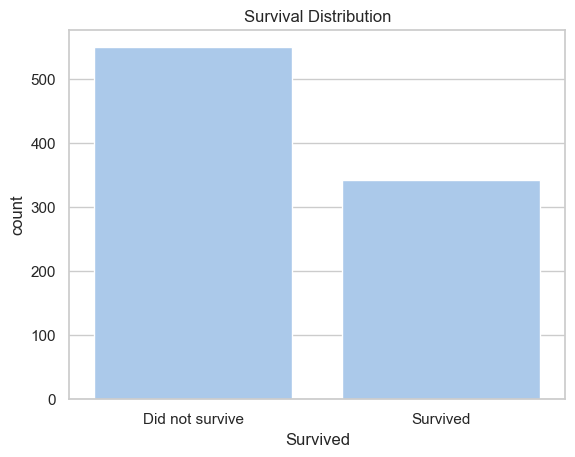

In [16]:
sns.countplot(data=df, x='Survived')
plt.title('Survival Distribution')
plt.xticks([0,1], ['Did not survive', 'Survived'])
plt.show()

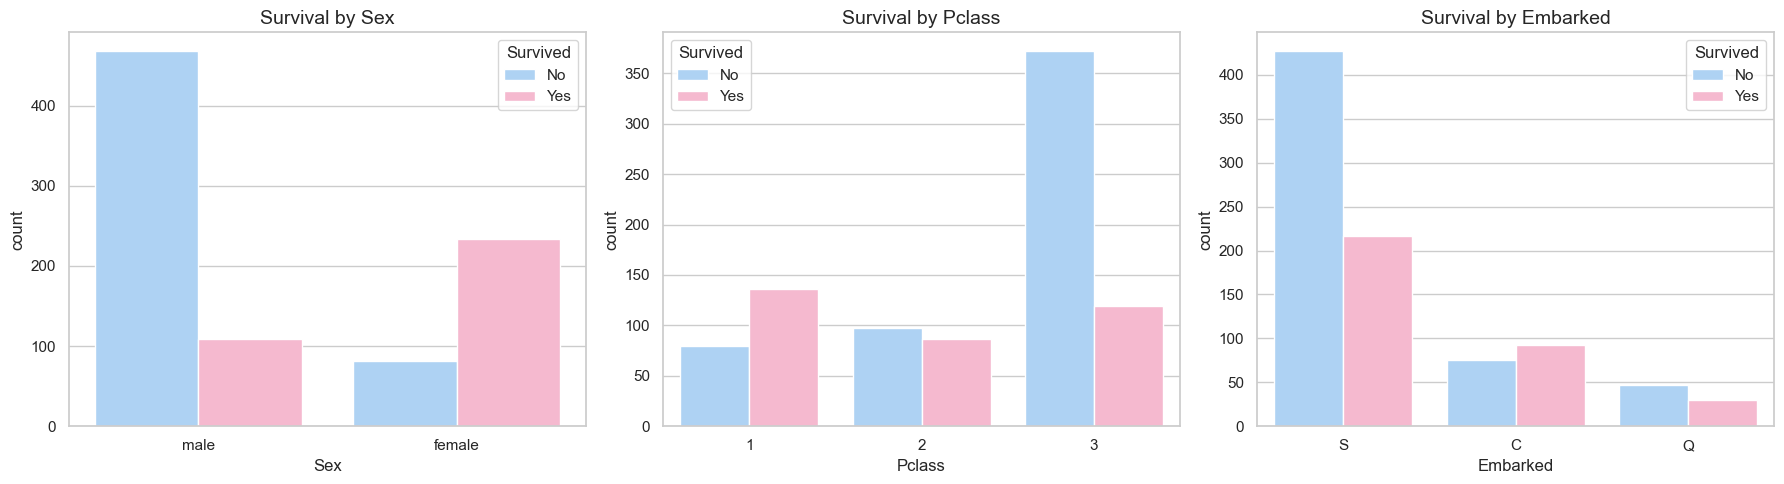

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

categorical_vars = ['Sex', 'Pclass', 'Embarked']

for i, var in enumerate(categorical_vars):
    sns.countplot(
        data=df,
        x=var,
        hue='Survived',
        ax=axes[i],
        palette=palette
    )
    axes[i].set_title(f'Survival by {var}', fontsize=14)
    axes[i].legend(title='Survived', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

* The plots clearly show that **females** had a much higher survival rate than males.
* This aligns with the historical evacuation protocol of *“women and children first.”*
* The difference is very strong, making `Sex` one of the most predictive variables.


* **First-class passengers (Pclass = 1)** show significantly higher survival.
* **Third-class passengers (Pclass = 3)** have the lowest survival.

* `Fare` reinforces this:
  * Survivors tend to have **higher fares on average**.
  * This acts as a proxy for **socioeconomic status**.



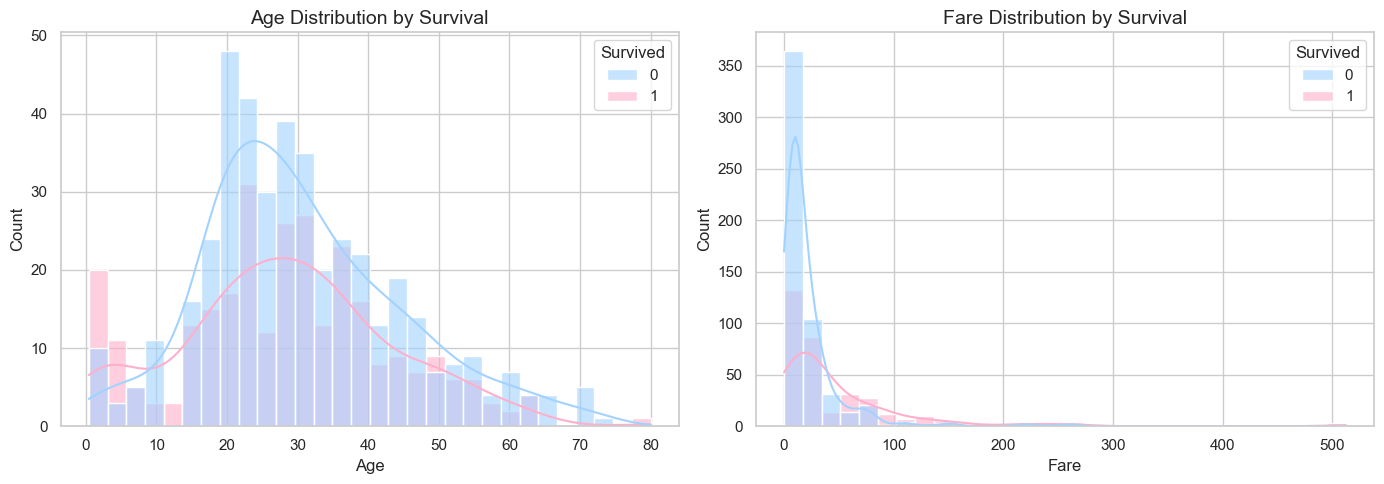

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

numerical_vars = ['Age', 'Fare']

for i, var in enumerate(numerical_vars):
    sns.histplot(
        data=df,
        x=var,
        hue='Survived',
        bins=30,
        kde=True,
        ax=axes[i],
        palette=palette,
        alpha=0.6
    )
    axes[i].set_title(f'{var} Distribution by Survival', fontsize=14)

plt.tight_layout()
plt.show()

* Age distributions overlap heavily between survivors and non-survivors.
* However, there is a slight increase in survival among younger passengers (children).
* Passengers embarking at **C (Cherbourg)** show relatively higher survival rates.



C:\Users\Ale\AppData\Local\Temp\ipykernel_42312\2515750058.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Ale\AppData\Local\Temp\ipykernel_42312\2515750058.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


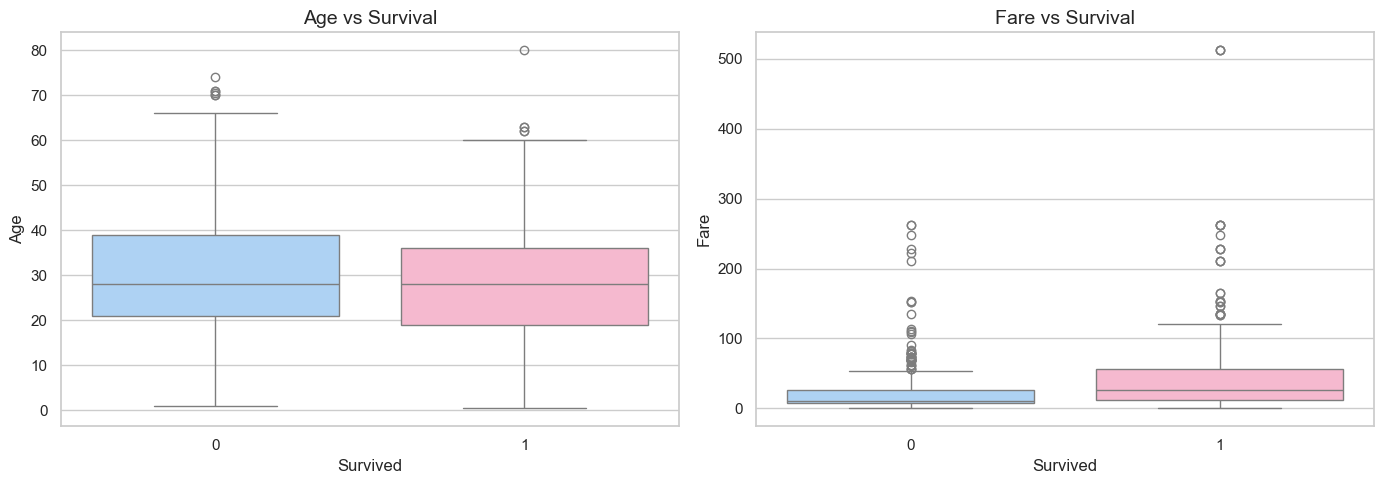

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, var in enumerate(numerical_vars):
    sns.boxplot(
        data=df,
        x='Survived',
        y=var,
        ax=axes[i],
        palette=palette
    )
    axes[i].set_title(f'{var} vs Survival', fontsize=14)

plt.tight_layout()
plt.show()

### **Analysis**

The exploratory analysis reveals that survival was strongly influenced by gender and socioeconomic status. Female passengers had significantly higher survival rates, consistent with evacuation protocols prioritizing women and children. Additionally, passengers in higher classes and those paying higher fares were more likely to survive, suggesting that access to resources and location within the ship played a critical role. Age alone was not a strong predictor, although children showed slightly higher survival rates. Finally, passengers embarking at Cherbourg exhibited higher survival, likely due to their association with higher passenger classes rather than embarkation location itself.

## **2. Preprocessing**

The `Cabin` column is first analyzed before deciding how to handle it.
To simplify the feature:

* Only the **first letter** of each cabin value is extracted, representing the deck.
* Missing values are imputed with the label **"Unknown"**.

In [21]:
df1 =  df.copy()

In [23]:
df1['Deck'] = df1['Cabin'].str[0]
df1['Deck'] = df1['Deck'].fillna('Uknown')

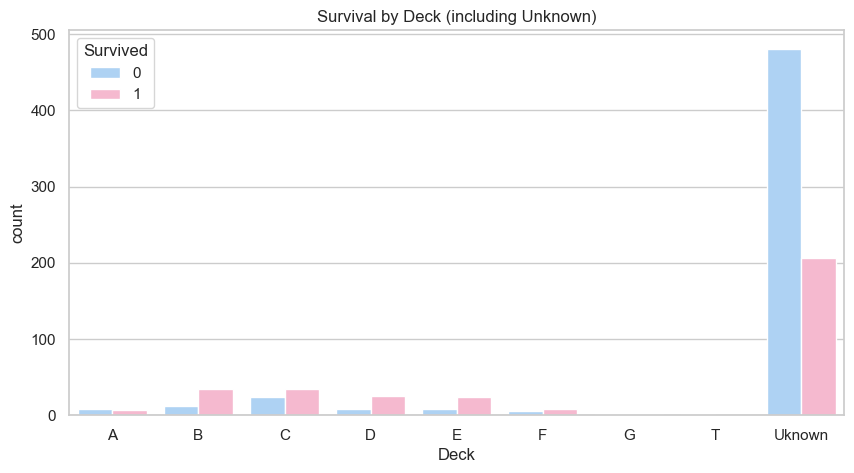

In [26]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df1,
    x='Deck',
    hue='Survived',
    palette=["#A2D2FF", "#FFAFCC"],
    order=sorted(df1['Deck'].unique())
)

plt.title('Survival by Deck (including Unknown)')
plt.show()


After visualization, it is observed that:

* Passengers with cabin information have a **higher survival rate**.
* However, the distribution across individual decks is **sparse and imbalanced**, making one-hot encoding less effective.

In [27]:
df1['HasCabin'] = df1['Cabin'].notnull().astype(int)

Therefore, instead of encoding each deck, the feature is transformed into a binary variable:

* `HasCabin = 1` if cabin information is present
* `HasCabin = 0` otherwise

This approach captures the most relevant signal while avoiding sparsity.


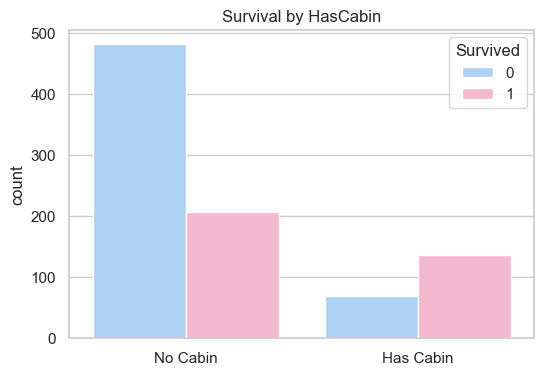

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df1,
    x='HasCabin',
    hue='Survived',
    palette=["#A2D2FF", "#FFAFCC"]
)

plt.title('Survival by HasCabin')
plt.xticks([0,1], ['No Cabin', 'Has Cabin'])
plt.xlabel('')
plt.show()

The cleaning function preprocesses the Titanic dataset by removing irrelevant features (`PassengerId`, `Name`, and `Ticket`), transforming the `Cabin` column into a binary feature (`HasCabin`) to capture potential socioeconomic information, and handling missing values in a structured way. 

In [69]:
def cleaning(df):
    # Drop irrelevant columns
    df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)
    
    # Feature engineering
    df['HasCabin'] = df['Cabin'].notnull().astype(int)
    df = df.drop(['Cabin'], axis=1)      
    return df

In [70]:
df_cleaned = cleaning(df)

In [71]:
df_cleaned.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin
0,0,3,male,22.0,1,0,7.2500,S,0
1,1,1,female,38.0,1,0,71.2833,C,1
2,1,3,female,26.0,0,0,7.9250,S,0
3,1,1,female,35.0,1,0,53.1000,S,1
4,0,3,male,35.0,0,0,8.0500,S,0


To ensure a robust evaluation of the model, the dataset is divided into three subsets:
- **Training set**: used to train the model  
- **Validation set**: used for hyperparameter tuning and model selection  
- **Test set**: used for final performance evaluation  

The split is performed using a custom function that maintains class distribution through **stratification**.

In [ ]:
def train_val_test_split(df, rstate=42, shuffle=True, stratify=None):
    strat = df[stratify] if stratify else None
    train_set, test_set = train_test_split(
        df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify else None
    val_set, test_set = train_test_split(
        test_set, test_size=0.5, random_state=rstate, shuffle=shuffle, stratify=strat)
    return (train_set, val_set, test_set)

def remove_labels(df, label_name):
    X = df.drop(label_name, axis=1)
    y = df[label_name].copy()
    return (X, y)

In [73]:
train_set, val_set, test_set = train_val_test_split(df_cleaned, stratify='Survived')

In [76]:
X_train, y_train = remove_labels(train_set, 'Survived')
X_val, y_val = remove_labels(val_set, 'Survived')
X_test, y_test = remove_labels(test_set, 'Survived')

To ensure a consistent and scalable preprocessing workflow, we implement a custom pipeline using `scikit-learn` that automatically handles both numeric and categorical features. This approach eliminates manual preprocessing and guarantees that all transformations are applied consistently across training, validation, and test sets.

It performs the following steps:

- **Automatic feature detection**
  - Numeric features: all non-object columns  
  - Categorical features: all object-type columns  

- **Numeric preprocessing**
  - Missing values → filled using the **median**
  - Features → standardized using **StandardScaler**

- **Categorical preprocessing**
  - Missing values → filled using the **most frequent value**
  - Encoding → transformed using **One-Hot Encoding**
  - Unknown categories → safely ignored during inference  

- **Feature reconstruction**
  - Combines numeric and encoded categorical features  
  - Preserves column names for interpretability  

In [77]:
class DataFramePreparer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.numeric_features_ = None
        self.categorical_features_ = None
        self.preprocess_ = None
        self.feature_names_ = None

    def fit(self, X, y=None):
        # Selección automática
        self.numeric_features_ = X.select_dtypes(exclude=["object"]).columns
        self.categorical_features_ = X.select_dtypes(include=["object"]).columns

        numeric_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ))
        ])

        self.preprocess_ = ColumnTransformer(
            transformers=[
                ("num", numeric_pipeline, self.numeric_features_),
                ("cat", categorical_pipeline, self.categorical_features_)
            ]
        )

        self.preprocess_.fit(X)

        # Construcción de nombres finales de columnas
        num_features = self.numeric_features_
        cat_features = self.preprocess_ \
            .named_transformers_["cat"] \
            .named_steps["onehot"] \
            .get_feature_names_out(self.categorical_features_)

        self.feature_names_ = list(num_features) + list(cat_features)

        return self

    def transform(self, X):
        X_transformed = self.preprocess_.transform(X)
        return pd.DataFrame(
            X_transformed,
            columns=self.feature_names_,
            index=X.index
        )


In [78]:
prep = DataFramePreparer()
prep.fit(X_train)

X_train_prep = prep.transform(X_train)
X_val_prep = prep.transform(X_val)
X_test_prep = prep.transform(X_test)

In [79]:
X_train_prep.head()

,Pclass,Age,SibSp,Parch,Fare,HasCabin,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
844,0.819472,-1.009092,-0.479956,-0.458433,-0.463691,-0.523892,0.0,1.0,0.0,0.0,1.0
316,-0.379427,-0.470634,0.620028,-0.458433,-0.114701,-0.523892,1.0,0.0,0.0,0.0,1.0
768,0.819472,-0.086022,0.620028,-0.458433,-0.151940,-0.523892,0.0,1.0,0.0,1.0,0.0
255,0.819472,-0.086022,-0.479956,1.965362,-0.331174,-0.523892,1.0,0.0,1.0,0.0,0.0
130,0.819472,0.221668,-0.479956,-0.458433,-0.479124,-0.523892,0.0,1.0,1.0,0.0,0.0


## **3.Training**

####  **3.1 Hyperparameter Optimization with Hyperband**

We implement the Hyperband algorithm to efficiently optimize the neural network architecture while balancing performance and computational cost. 

First, we define a `model_builder` function, which specifies the search space of hyperparameters to be explored. The optimization focuses on key architectural and training parameters, including:

- **Number of neurons (units)** per layer  
- **Number of hidden layers**  
- **Activation function** (ReLU or Tanh)  
- **Learning rate** of the optimizer  


In [90]:
n_features = X_train_prep.shape[1]

In [91]:
def model_builder(hp):
    model = keras.Sequential()
    model.add(keras.Input(shape=(n_features,)))

    hp_units = hp.Int('units', min_value=8, max_value=64, step=8)
    hp_layers = hp.Int('layers', min_value=1, max_value=5, step=1)
    hp_activation = hp.Choice('activation', values=['relu', 'tanh'])

    for _ in range(hp_layers):
        model.add(layers.Dense(units=hp_units, activation=hp_activation))

    model.add(layers.Dense(1, activation='sigmoid'))

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
    )
    return model

We apply the Hyperband algorithm using Keras Tuner to efficiently explore different neural network configurations. A maximum of 50 epochs is defined as the upper limit for training. To prevent unnecessary training and reduce overfitting, we implement **early stopping mechanism**. 

This callback monitors the validation loss and stops training when no improvement is observed for a specified number of epochs, while restoring the best model weights.

During the search process, Hyperband evaluates various combinations of hyperparameters defined in the `model_builder` function. At the end of the optimization, the best-performing configuration is selected based on validation accuracy.

In [92]:
tuner = kt.Hyperband(
    model_builder,
    objective='val_accuracy',
    max_epochs=50,
    factor=3,
    directory='keras_tuner_dir',
    project_name='titanic_hyperband'
)

stop_early = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

tuner.search(
    X_train_prep, y_train,
    epochs=30,
    validation_data=(X_val_prep, y_val),
    callbacks=[stop_early]
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n Best Configuration (Hyperband)")
print("-" * 40)
print(f"Layers          : {best_hps.get('layers')}")
print(f"Units/layer     : {best_hps.get('units')}")
print(f"Activation      : {best_hps.get('activation')}")
print(f"Learning rate   : {best_hps.get('learning_rate'):.4f}")
print("-" * 40)

Trial 90 Complete [00h 00m 04s]
val_accuracy: 0.8651685118675232

Best val_accuracy So Far: 0.8651685118675232
Total elapsed time: 00h 03m 47s

 Best Configuration (Hyperband)
----------------------------------------
Layers          : 1
Units/layer     : 24
Activation      : tanh
Learning rate   : 0.0100
----------------------------------------


Finally, we train the model with the best hyperparameters

In [93]:
best_model = tuner.hypermodel.build(best_hps)

history = best_model.fit(
    X_train_prep, y_train,
    epochs=50,
    validation_data=(X_val_prep, y_val),
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    )]
)


Epoch 1/50
17/17 [==============================] - 1s 17ms/step - loss: 0.5152 - accuracy: 0.7434 - auc: 0.8162 - val_loss: 0.4526 - val_accuracy: 0.7865 - val_auc: 0.8529
Epoch 2/50
17/17 [==============================] - 0s 6ms/step - loss: 0.4538 - accuracy: 0.7921 - auc: 0.8512 - val_loss: 0.4168 - val_accuracy: 0.8315 - val_auc: 0.8694
Epoch 3/50
17/17 [==============================] - 0s 4ms/step - loss: 0.4386 - accuracy: 0.7884 - auc: 0.8642 - val_loss: 0.4187 - val_accuracy: 0.8258 - val_auc: 0.8681
Epoch 4/50
17/17 [==============================] - 0s 4ms/step - loss: 0.4364 - accuracy: 0.8052 - auc: 0.8625 - val_loss: 0.4173 - val_accuracy: 0.8371 - val_auc: 0.8691
Epoch 5/50
17/17 [==============================] - 0s 5ms/step - loss: 0.4308 - accuracy: 0.8146 - auc: 0.8673 - val_loss: 0.4112 - val_accuracy: 0.8258 - val_auc: 0.8775
Epoch 6/50
17/17 [==============================] - 0s 4ms/step - loss: 0.4311 - accuracy: 0.7996 - auc: 0.8648 - val_loss: 0.4148 - val_ac

In [116]:
thresholds = np.linspace(0.1, 0.9, 50)
f1_scores = []

for t in thresholds:
    y_pred = (y_pred_val_proba >= t).astype(int)
    f1_scores.append(f1_score(y_val, y_pred))

best_threshold = thresholds[np.argmax(f1_scores)]
print("Best threshold:", best_threshold)

Best threshold: 0.5244897959183674


In [119]:
y_pred_val_proba = best_model.predict(X_val_prep).flatten()
y_pred_val_best = (y_pred_val_proba >= best_threshold).astype(int)

6/6 [==============================] - 0s 2ms/step


## **4. Model Evaluation**

In [120]:
acc_val = accuracy_score(y_val, y_pred_val_best)
auc_val = roc_auc_score(y_val, y_pred_val_proba)
precision = precision_score(y_val, y_pred_val_best)
recall = recall_score(y_val, y_pred_val_best)
f1 = f1_score(y_val, y_pred_val_best)

# Confusion matrix
cm = confusion_matrix(y_val, y_pred_val_best)

print("\n===== VALIDATION METRICS =====")
print(f"Accuracy : {acc_val:.4f}")
print(f"AUC      : {auc_val:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_val, y_pred_val_best))


===== VALIDATION METRICS =====
Accuracy : 0.8539
AUC      : 0.8813
Precision: 0.9200
Recall   : 0.6765
F1-score : 0.7797

Confusion Matrix:
[[106   4]
 [ 22  46]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89       110
           1       0.92      0.68      0.78        68

    accuracy                           0.85       178
   macro avg       0.87      0.82      0.84       178
weighted avg       0.86      0.85      0.85       178



In [121]:
def confusion_matrix_heatmap(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="pink",
            xticklabels=["No Survive", "Survive"],
            yticklabels=["No Survive", "Survive"])

    plt.title("Confusion Matrix", fontsize=14)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


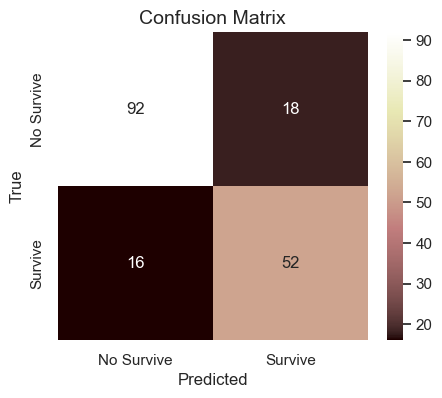

In [108]:
confusion_matrix_heatmap(y_val, y_pred_val_best)